# utils
> General plotting helpers, save utilities, and palette/color tools.

In [ ]:
#| default_exp utils

In [ ]:
#| export
import itertools
from itertools import cycle
from pathlib import Path

import matplotlib as mpl
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from statannotations.Annotator import Annotator

In [ ]:
df = sns.load_dataset('tips')
df.shape

(244, 7)

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Setup Helpers

In [ ]:
#| export
def set_sns(dpi: int = 300) -> None:
    "Set seaborn defaults for notebook display and saved figures."
    sns.set(rc={"figure.dpi": dpi, "savefig.dpi": dpi})
    sns.set_context('notebook')
    sns.set_style('ticks')

In [ ]:
set_sns(dpi=50)

In [ ]:
#| export
def save_svg(path: str | Path) -> None:
    "Save the current matplotlib figure as SVG with editable text."
    plt.rcParams['svg.fonttype'] = 'none'
    plt.savefig(path, format='svg', bbox_inches='tight', transparent=True)

[<matplotlib.lines.Line2D>]

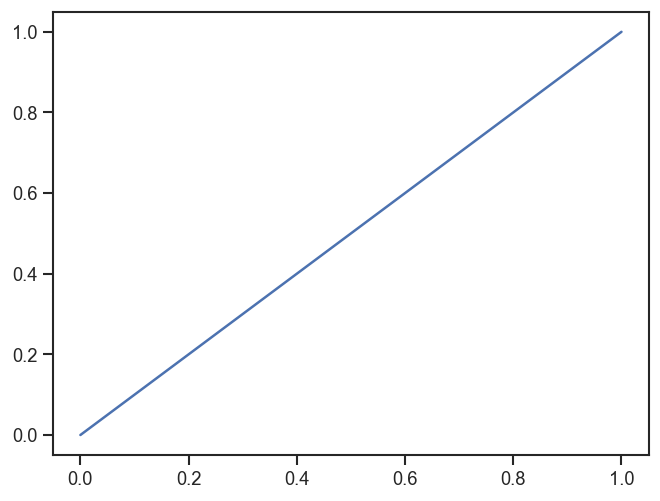

In [ ]:
plt.figure()
plt.plot([0, 1], [0, 1])
# save_svg(Path('nbs') / '_tmp_utils.svg')

In [ ]:
#| export
def save_pdf(path: str | Path) -> None:
    "Save the current matplotlib figure as PDF with TrueType fonts."
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    plt.savefig(path, format='pdf', bbox_inches='tight', transparent=True)

[<matplotlib.lines.Line2D>]

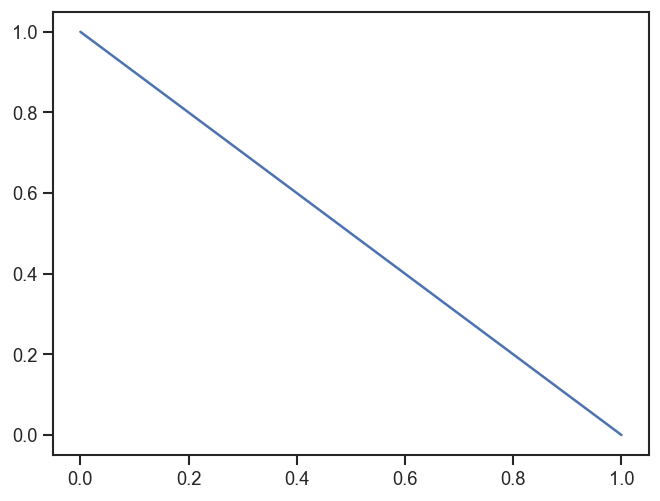

In [ ]:
plt.figure()
plt.plot([0, 1], [1, 0])
# save_pdf(Path('nbs') / '_tmp_utils.pdf')

In [ ]:
#| export
def save_show(
    path: str | Path | None = None,  # output path when saving instead of showing
    show_only: bool = False,  # force plt.show even when no path is provided
) -> None:
    "Show the current figure or save it, then close open figures."
    if show_only:
        plt.show()
    elif path is not None:
        plt.savefig(path, bbox_inches='tight', pad_inches=0.05, transparent=True)
    else:
        plt.show()
    plt.close('all')

[<matplotlib.lines.Line2D>]

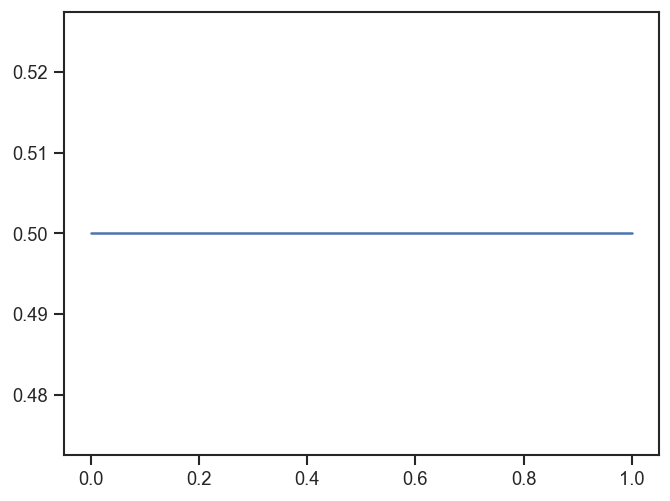

In [ ]:
plt.figure()
plt.plot([0, 1], [0.5, 0.5])
# save_show(path=Path('nbs') / '_tmp_utils_show.png')

## Palette Helpers

In [ ]:
#| export
def get_color_dict(
    categories: list[str],  # labels that need colors
    palette: str = 'tab20',  # seaborn palette name
) -> dict[str, tuple[float, float, float]]:
    "Assign colors to labels while tolerating duplicate category names."
    colors = sns.color_palette(palette)
    color_cycle = cycle(colors)
    return {category: next(color_cycle) for category in categories}

In [ ]:
get_color_dict(['A', 'B', 'C'], palette='Set2')

{'A': (0.4, 0.7607843137254902, 0.6470588235294118),
 'B': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 'C': (0.5529411764705883, 0.6274509803921569, 0.796078431372549)}

In [ ]:
#| export
def get_plt_color(
    palette: dict | list | str,  # dict lookup, explicit list, or palette name
    columns: list[str],  # plotted column names in output order
) -> list:
    "Return colors in plotting order for a dict, list, or named palette."
    if isinstance(palette, dict):
        return [palette.get(col, '#cccccc') for col in columns]
    if isinstance(palette, str):
        return sns.color_palette(palette, n_colors=len(columns))
    if isinstance(palette, list):
        return palette
    raise TypeError('palette must be a dict, list, or seaborn palette name')

In [ ]:
get_plt_color('Set2', ['a', 'b'])

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

In [ ]:
#| export
def get_hue_big(
    df: pd.DataFrame,  # source dataframe
    hue_col: str,  # categorical column used for hue
    cnt_thr: int = 10,  # minimum count retained in the filtered hue series
) -> pd.Series:
    "Filter a hue column down to categories that meet a count threshold."
    counts = df[hue_col].value_counts()
    keep = counts[counts >= cnt_thr].index
    return df[hue_col][df[hue_col].isin(keep)]

In [ ]:
# get_hue_big(df, 'day', cnt_thr=40).tolist()

## Statistical Annotations

In [ ]:
#| export
def add_stats(ax,
              df,
              value,
              group,
              test='t-test_ind',
              loc='inside',
              text_format='star',
              min_n=3,
              **kwargs):
    """
    If `value` is str:
        compare between groups (x=group, y=value)
    If `value` is list/tuple:
        compare among values within each group (x=group, hue='variable')
    """

    # -----------------------------
    # Case 1: value is a single column -> compare groups
    # -----------------------------
    if isinstance(value, str):
        # get x axis labels from the plot
        order = [t.get_text() for t in ax.get_xticklabels()]

        # Build all between-group pairs, but skip too-small samples
        pairs = []
        for g1, g2 in itertools.combinations(order, 2):
            d1 = df.loc[df[group] == g1, value].dropna()
            d2 = df.loc[df[group] == g2, value].dropna()
            if len(d1) >= min_n and len(d2) >= min_n:
                pairs.append((g1, g2))

        if len(pairs) == 0:
            print('No valid group-vs-group comparisons (check sample sizes).')
            return ax

        annotator = Annotator(ax, pairs, data=df, x=group, y=value, order=order)
        annotator.configure(test=test, text_format=text_format, loc=loc,
                            verbose=False, **kwargs)
        annotator.apply_and_annotate()
        return ax

    # -----------------------------
    # Case 2: value is list/tuple -> compare values within each group
    # -----------------------------
    if not isinstance(value, (list, tuple)):
        raise TypeError('`value` must be a column name (str) or a list/tuple of column names.')

    df_melted = df.melt(id_vars=group, value_vars=list(value)).dropna(subset=['value'])

    pairs = []
    for g in df_melted[group].unique():
        sub = df_melted[df_melted[group] == g]
        vars_in_group = sub['variable'].unique()

        for v1, v2 in itertools.combinations(vars_in_group, 2):
            d1 = sub.loc[sub['variable'] == v1, 'value']
            d2 = sub.loc[sub['variable'] == v2, 'value']
            if len(d1) >= min_n and len(d2) >= min_n:
                pairs.append(((g, v1), (g, v2)))

    if len(pairs) == 0:
        print('No valid within-group comparisons (check sample sizes).')
        return ax

    annotator = Annotator(ax, pairs, data=df_melted, x=group, y='value', hue='variable')
    annotator.configure(test=test, text_format=text_format, loc=loc,
                        verbose=False, **kwargs)
    annotator.apply_and_annotate()
    return ax

<Axes: xlabel='sex', ylabel='total_bill'>

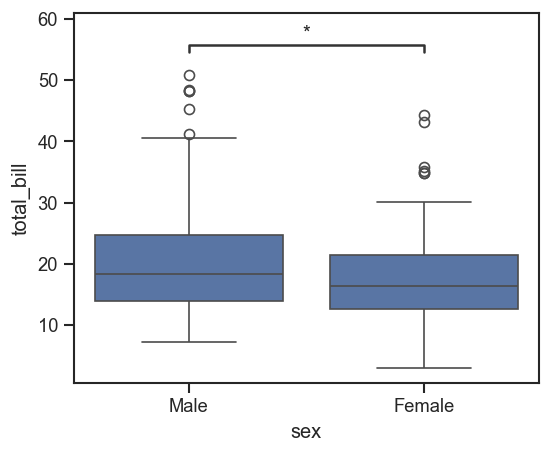

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x='sex', y='total_bill', ax=ax)
add_stats(ax, df, value='total_bill', group='sex')

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()